In [23]:
import h5py
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner

from jesterTOV.inference.population.populations import RecycledBinary

# load EOS
m_val, r_val, l_val = np.loadtxt("../../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_val.max()
n_val, p_val = np.loadtxt("../../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])


latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }


In [30]:
2.8/mtov

np.float64(1.3056413030300202)

In [27]:
def load_population_posterior(file):

    posterior = {}

    with h5py.File(file) as f:

        for key in ["mu_1", "mu_2", "alpha", "sigma_1", "sigma_2", "m_max", "m_min", "k_coll"]:
            if key in f["posterior"]["parameters"].keys():
                posterior[key] = f["posterior"]["parameters"][key][:]
    
    return pd.DataFrame(posterior)

def load_eos_posterior(file):
    
    posterior = {}

    with h5py.File(file) as f:
        posterior["masses_EOS"] = f["posterior"]["derived_eos"]["masses_EOS"][:]
        posterior["radii_EOS"] = f["posterior"]["derived_eos"]["radii_EOS"][:]
        posterior["lambdas_EOS"] = f["posterior"]["derived_eos"]["Lambdas_EOS"][:]
        posterior["log_prob"] = f["posterior"]["log_prob"][:]

    return posterior

posterior_gw = load_population_posterior("./gw/outdir_gw/results.h5")
posterior_mm = load_population_posterior("./mm/outdir_mm/results.h5")
eos_posterior_gw = load_eos_posterior("./gw/outdir_gw/results.h5")
eos_posterior_mm = load_eos_posterior("./mm/outdir_mm/results.h5")


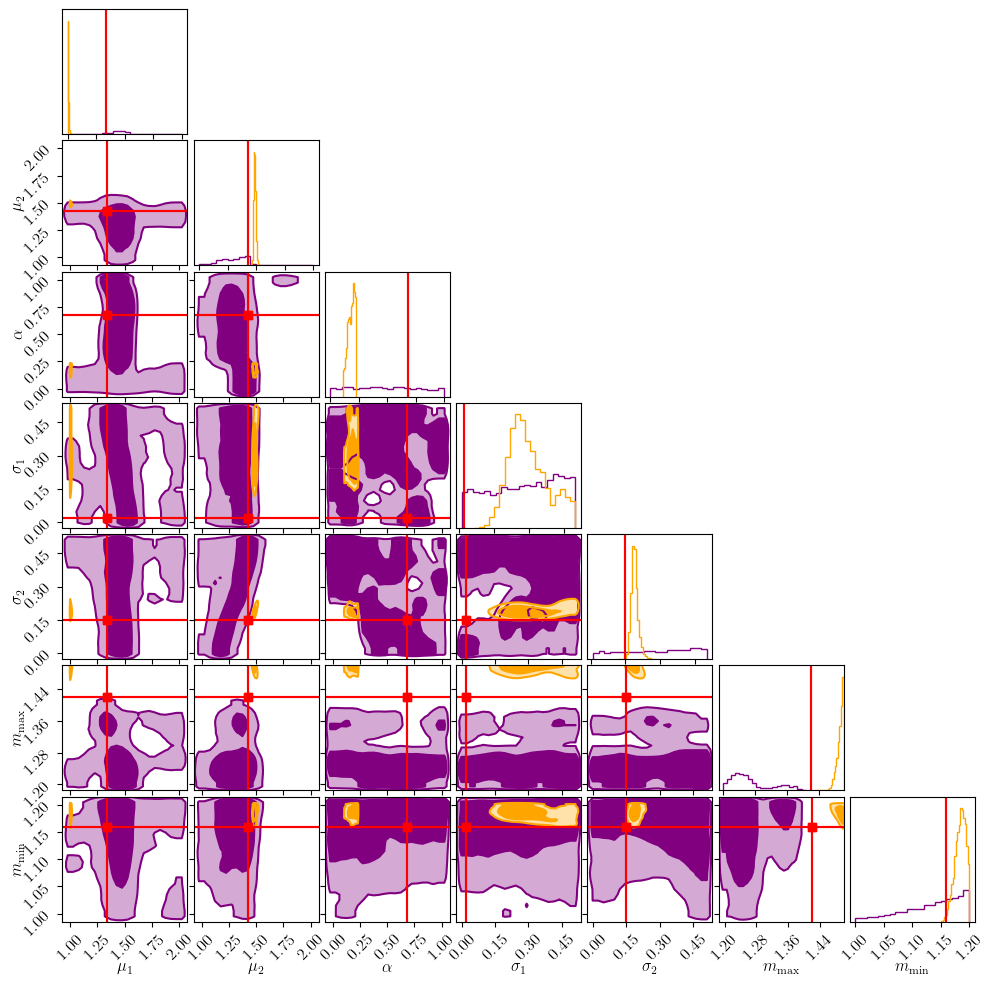

In [32]:
def corner_plot(posterior, parameter_names, ax, color="purple"):

    truths = dict(mu_1=1.34, mu_2=1.43, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42, k_coll=1.3)

    labels = [latex_labels.get(p,p) for p in parameter_names]

    corner.corner(posterior[parameter_names], 
                  smooth=True, 
                  levels=[0.68, 0.95],
                  fig=fig, 
                  plot_density=False,
                  fill_contours=True,
                  plot_datapoints=False,
                  truths=truths,
                  color=color,
                  truth_color="red",
                  labels=labels,
                  hist_kwargs=dict(density=True))


fig, ax = plt.subplots(7,7 , figsize=(10, 10))

corner_plot(posterior_gw, list(posterior_gw.keys()), fig)
corner_plot(posterior_mm, list(posterior_gw.keys()), fig, color="orange")

fig.show()

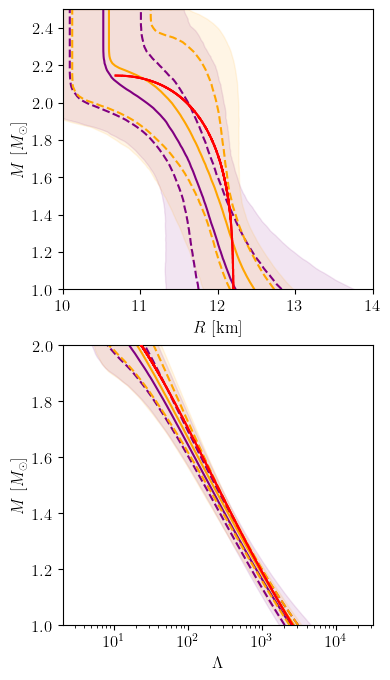

In [79]:
def plot_eos(eos_posterior, ax, quantity="radii_EOS", color="purple"):

    quantity_interp = np.vstack([
                                np.interp(m_arr, eos_posterior["masses_EOS"][j,:], eos_posterior[quantity][j,:], left=np.nan) 
                                     for j in range(eos_posterior_gw["masses_EOS"].shape[0]) 
    ])
    
    quantiles = np.vstack([
                           corner.quantile(quantity_interp[:, j], q=[0.025, 0.16, 0.5, 0.84, 0.975])
                           for j in range(m_arr.shape[0])
    ])
    
    ax.plot(quantiles[:, 2], m_arr, color=color)
    ax.plot(quantiles[:, 1], m_arr, color=color, linestyle="dashed")
    ax.plot(quantiles[:, 3], m_arr, color=color, linestyle="dashed")
    ax.fill_betweenx(m_arr, quantiles[:, 0], quantiles[:, 4], color=color, alpha=0.1)

    if quantity=="lambdas_EOS":
        ax.plot(l_val, m_val, color="red", zorder=3)
    else:
        ax.plot(r_val, m_val, color="red", zorder=3)

fig, ax = plt.subplots(2,1,figsize=(4,8))
m_arr = np.linspace(1, 2.5, 120)


plot_eos(eos_posterior_gw, ax[0])
plot_eos(eos_posterior_mm, ax[0], color="orange")
ax[0].set_ylabel("$M$ [$M_\\odot$]")
ax[0].set_xlabel("$R$ [km]")
ax[0].set(ylim=(1, 2.5), xlim=(10, 14))



plot_eos(eos_posterior_gw, ax[1], "lambdas_EOS")
plot_eos(eos_posterior_mm, ax[1], "lambdas_EOS", color="orange")
ax[1].set_ylabel("$M$ [$M_\\odot$]")
ax[1].set_xlabel("$\\Lambda$")
ax[1].set(ylim=(1, 2), xscale="log")


fig.show()


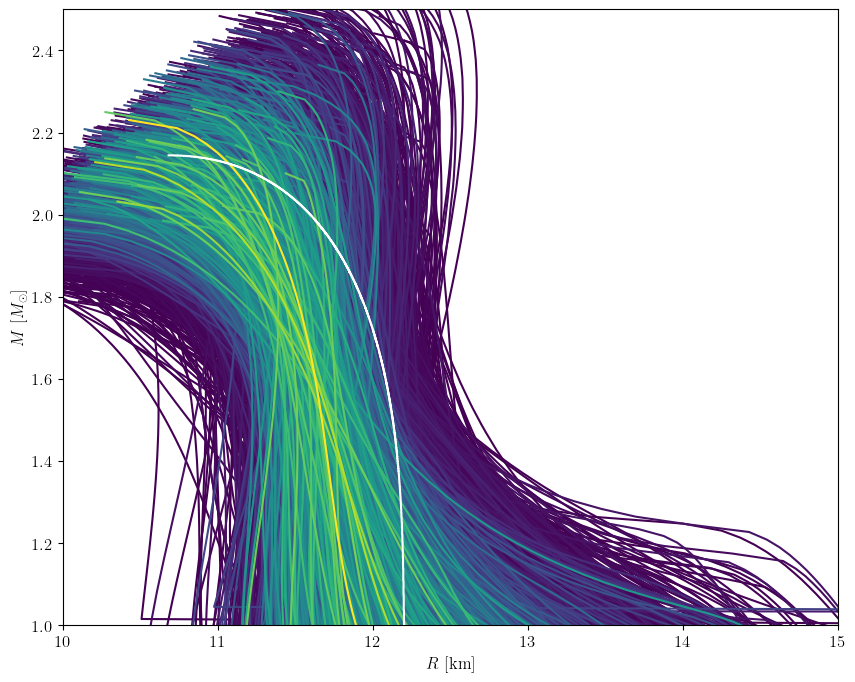

In [9]:
fig, ax = plt.subplots(figsize=(10,8))
m_min, m_max = 1.0, 2.0

# Normalize probabilities for coloring
prob = np.exp(log_prob - np.max(log_prob))  # Normalize to avoid overflow
norm = Normalize(vmin=np.min(prob), vmax=np.max(prob))
cmap = plt.get_cmap("viridis")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

valid_indices = []
mtov_max = 0.0
for i in range(len(prob)):
    # Skip invalid samples (same checks as plotting loop)
    if any(np.isnan(masses_eos[i])) or any(np.isnan(lambdas_eos[i])):
        continue
    if any(lambdas_eos[i] < 0):
        continue

    # This is a valid sample
    valid_indices.append(i)


    mtov = np.max(masses_eos[i])
    mtov_max = max(mtov_max, mtov)

    # Get color based on probability
    normalized_value = norm(prob[i])
    color = cmap(normalized_value)

    ax.plot(radii_eos[i],
            masses_eos[i],
            color=color,
            alpha=1.0,
            rasterized=True,
            zorder=normalized_value,
        )
    
ax.set_ylabel("$M$ [$M_{\\odot}$]")
ax.set_xlabel("$R$ [km]")
ax.set_ylim((1.0, 2.5))
ax.set_xlim((10, 15))

ax.plot(r_val, m_val, color="white", zorder=3)

In [11]:
events = pd.read_csv("../events.dat", sep=" ")
mass_1_samp, mass_2_samp = RecycledBinary({"alpha": 0.68}, size=20_000)

(array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.49, 2.94, 3.43, 2.94,
        2.45, 4.9 , 4.41, 5.88, 4.41, 9.8 , 5.88, 0.98, 0.49, 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  ]),
 array([1.        , 1.02040816, 1.04081633, 1.06122449, 1.08163265,
        1.10204082, 1.12244898, 1.14285714, 1.16326531, 1.18367347,
        1.20408163, 1.2244898 , 1.24489796, 1.26530612, 1.28571429,
        1.30612245, 1.32653061, 1.34693878, 1.36734694, 1.3877551 ,
        1.40816327, 1.42857143, 1.44897959, 1.46938776, 1.48979592,
        1.51020408, 1.53061224, 1.55102041, 1.57142857, 1.59183673,
        1.6122449 , 1.63265306, 1.65306122, 1.67346939, 1.69387755,
        1.71428571, 1.73469388, 1.75510204, 1.7755102 , 1.79591837,
        1.81632653, 1.83673469, 1.85714286, 1.87755102, 1.89795918,
        1.91836735, 1.93877551, 1.95918367, 1.979591

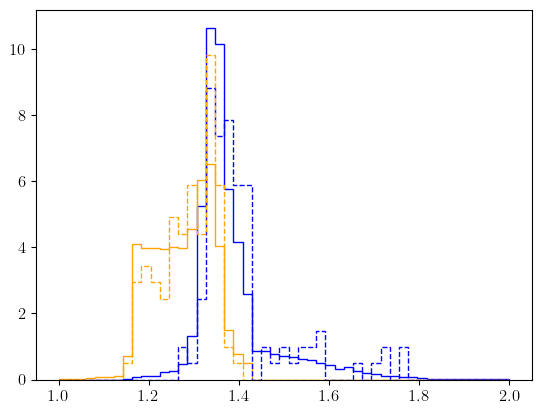

In [12]:
bins=np.linspace(1, 2, 50)

plt.hist(mass_1_samp, bins=bins, color="blue", histtype="step", density=True)
plt.hist(mass_2_samp, bins=bins, color="orange", histtype="step", density=True)

plt.hist(events.loc[:100, "mass_1_source"], bins=bins, color="blue", histtype="step", density=True, linestyle="dashed")
plt.hist(events.loc[:100, "mass_2_source"], bins=bins, color="orange", histtype="step", density=True, linestyle="dashed")

In [ ]:
# Normalize probabilities for coloring
prob = np.exp(log_prob - np.max(log_prob))  # Normalize to avoid overflow
norm = Normalize(vmin=np.min(prob), vmax=np.max(prob))
cmap = plt.get_cmap("viridis")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

valid_indices = []
mtov_max = 0.0
for i in range(len(prob)):
    # Skip invalid samples (same checks as plotting loop)
    if any(np.isnan(masses_eos[i])) or any(np.isnan(lambdas_eos[i])):
        continue
    if any(lambdas_eos[i] < 0):
        continue

    # This is a valid sample
    valid_indices.append(i)
    mtov = np.max(masses_eos[i])
    mtov_max = max(mtov_max, mtov)

    # Get color based on probability
    normalized_value = norm(prob[i])
    color = cmap(normalized_value)

    ax.plot(
            masses_eos[i],
            lambdas_eos[i],
            color=color,
            alpha=1.0,
            rasterized=True,
            zorder=normalized_value,
        )
    
ax.set_xlabel("$M$ [$M_{\\odot}$]")
ax.set_ylabel("$\\Lambda$")
ax.set_xlim((1.2, 2.0))
ax.set_yscale("log")
ax.set_ylim((10, 1e4))

'''
cbar_ax = fig.add_axes((0.15, 0.94, 0.7, 0.03))  # tuple for type checker
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Normalized posterior probability", fontsize=16)
cbar.set_ticks([])
cbar.ax.xaxis.labelpad = 5
cbar.ax.tick_params(labelsize=0, length=0)
cbar.ax.xaxis.set_label_position("top")
'''


ax.plot(m_val, l_val, color="white", zorder=3)